In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv("D:\\Fraud Detection model project 2\\Raw_dataset\\financial_fraud_detection_cleaned.csv")

print("dataset loaded successfully")
print("rows:", df.shape[0])
print("columns:", df.shape[1])

dataset loaded successfully
rows: 5000
columns: 14


In [57]:
print(df["Transaction_Date"].head())
print(df["Transaction_Date"].dtypes)

0   NaT
1   NaT
2   NaT
3   NaT
4   NaT
Name: Transaction_Date, dtype: datetime64[s]
datetime64[s]


In [31]:
df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
0,T100000,CUST3252,2023-10-04 07:45:00,37.54,Travel,PayPal,POS,Bengaluru,0,94,417.40,1492,No,0
1,T100001,CUST1630,2023-09-26 08:29:00,240.81,Utilities,PayPal,Mobile,Bengaluru,0,76,335.47,66,No,0
2,T100002,CUST7852,2023-07-18 15:54:00,105.34,Entertainment,Debit Card,Mobile,Bengaluru,0,60,432.03,216,No,0
3,T100003,CUST4892,2023-10-16 17:10:00,73.04,Utilities,NetBanking,Desktop,Kolkata,0,68,488.30,449,No,0
4,T100004,CUST8831,2023-09-09 00:46:00,13.57,Utilities,Credit Card,Desktop,Bengaluru,0,57,437.03,754,No,0


In [32]:
df.tail()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Merchant_Category,Payment_Method,Device_Type,Location,Is_International,Previous_Transactions,Average_Spend,Account_Age_Days,Suspicious_Keyword,Fraudulent
4995,T104995,CUST3702,2023-08-01 21:20:00,182.15,Electronics,Debit Card,Mobile,Kolkata,0,13,277.99,840,No,0
4996,T104996,CUST6007,2024-01-14 16:42:00,10.17,Fashion,Credit Card,Desktop,Chennai,0,128,477.24,441,No,0
4997,T104997,CUST6812,2023-01-09 22:14:00,31.78,Grocery,Debit Card,Mobile,Kolkata,1,76,442.62,1474,No,1
4998,T104998,CUST9120,2023-08-18 17:15:00,135.31,Utilities,Debit Card,Mobile,Bengaluru,0,13,73.33,246,No,0
4999,T104999,CUST1080,2023-09-07 21:20:00,72.77,Entertainment,UPI,Mobile,Bengaluru,0,146,30.23,699,No,0


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Transaction_ID         5000 non-null   str    
 1   Customer_ID            5000 non-null   str    
 2   Transaction_Date       5000 non-null   str    
 3   Transaction_Amount     5000 non-null   float64
 4   Merchant_Category      5000 non-null   str    
 5   Payment_Method         5000 non-null   str    
 6   Device_Type            5000 non-null   str    
 7   Location               5000 non-null   str    
 8   Is_International       5000 non-null   int64  
 9   Previous_Transactions  5000 non-null   int64  
 10  Average_Spend          5000 non-null   float64
 11  Account_Age_Days       5000 non-null   int64  
 12  Suspicious_Keyword     5000 non-null   str    
 13  Fraudulent             5000 non-null   int64  
dtypes: float64(2), int64(4), str(8)
memory usage: 859.3 KB


In [34]:
# checking fraudulent variable in the dataset
df['Fraudulent'].value_counts()


Fraudulent
0    4518
1     482
Name: count, dtype: int64

In [64]:
print(type(df["Transaction_Date"]))
print(df["Transaction_Date"].dtype)
print(df["Transaction_Date"].iloc[0])
print(type(df["Transaction_Date"].iloc[0]))

<class 'pandas.Series'>
datetime64[s]
NaT
<class 'pandas.api.typing.NaTType'>


In [65]:
df = pd.read_csv("D:\\Fraud Detection model project 2\\Raw_dataset\\financial_fraud_detection_cleaned.csv")

print(df["Transaction_Date"].head(10))
print(df["Transaction_Date"].dtype)

0    2023-10-04 07:45:00
1    2023-09-26 08:29:00
2    2023-07-18 15:54:00
3    2023-10-16 17:10:00
4    2023-09-09 00:46:00
5    2024-01-14 03:15:00
6    2023-02-09 08:56:00
7    2023-03-26 13:12:00
8    2023-03-06 20:09:00
9    2023-06-27 12:06:00
Name: Transaction_Date, dtype: str
str


In [66]:
df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

In [67]:
print(df["Transaction_Date"].dtype)
print(df["Transaction_Date"].head())
print("Missing dates:", df["Transaction_Date"].isna().sum())

datetime64[us]
0   2023-10-04 07:45:00
1   2023-09-26 08:29:00
2   2023-07-18 15:54:00
3   2023-10-16 17:10:00
4   2023-09-09 00:46:00
Name: Transaction_Date, dtype: datetime64[us]
Missing dates: 0


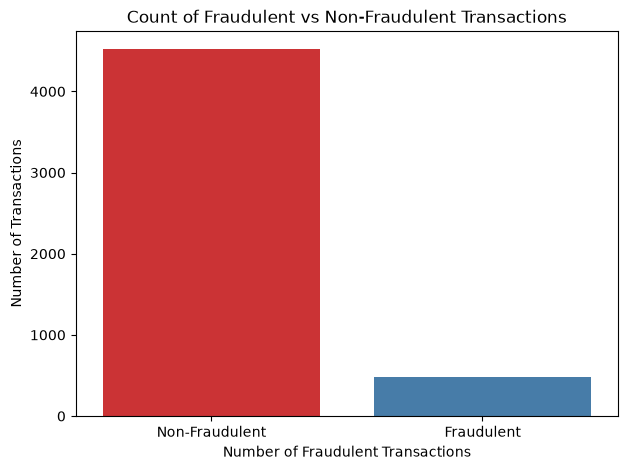

Count plot created successfully.


In [35]:
plt.figure(figsize=(7, 5))

sns.countplot(x='Fraudulent', data=df, hue='Fraudulent', palette='Set1', legend=False)

plt.title('Count of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('Number of Fraudulent Transactions')
plt.ylabel('Number of Transactions')

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

print("Count plot created successfully.")


In [36]:
df["Transaction_Amount"].describe()

df.groupby("Fraudulent")["Transaction_Amount"].describe()



,count,mean,std,min,25%,50%,75%,max
Fraudulent,,,,,,,,
0,4518.0,78.880558,77.776372,0.0,22.635,55.455,110.3725,595.34
1,482.0,81.993693,89.373791,0.0,21.490,55.430,109.2900,653.80


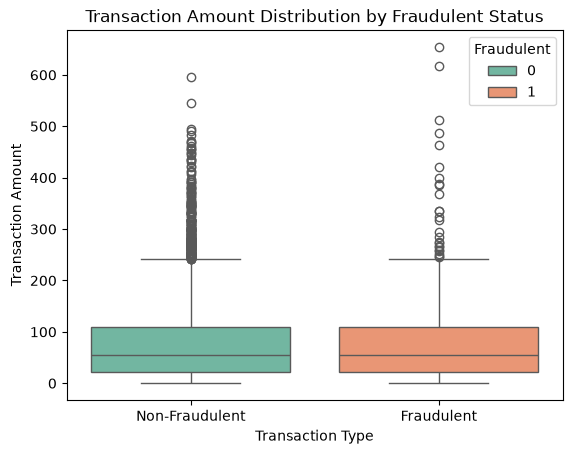

In [37]:
plt.Figure(figsize=(10, 6))

sns.boxplot( data=df, x='Fraudulent', y='Transaction_Amount', hue='Fraudulent', palette='Set2')

plt.title('Transaction Amount Distribution by Fraudulent Status')
plt.xlabel('Transaction Type')
plt.ylabel('Transaction Amount')

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])

plt.show()

In [38]:
# analyzing merchant category distribution for fraudulent and non-fraudulent transactions

df["Merchant_Category"].value_counts()

df.groupby("Fraudulent")["Merchant_Category"].value_counts()

Fraudulent  Merchant_Category
0           Food                 610
            Electronics          601
            Grocery              571
            Entertainment        558
            Fashion              546
            Health               545
            Utilities            544
            Travel               543
1           Food                  74
            Entertainment         72
            Fashion               62
            Health                61
            Grocery               58
            Travel                56
            Utilities             50
            Electronics           49
Name: count, dtype: int64

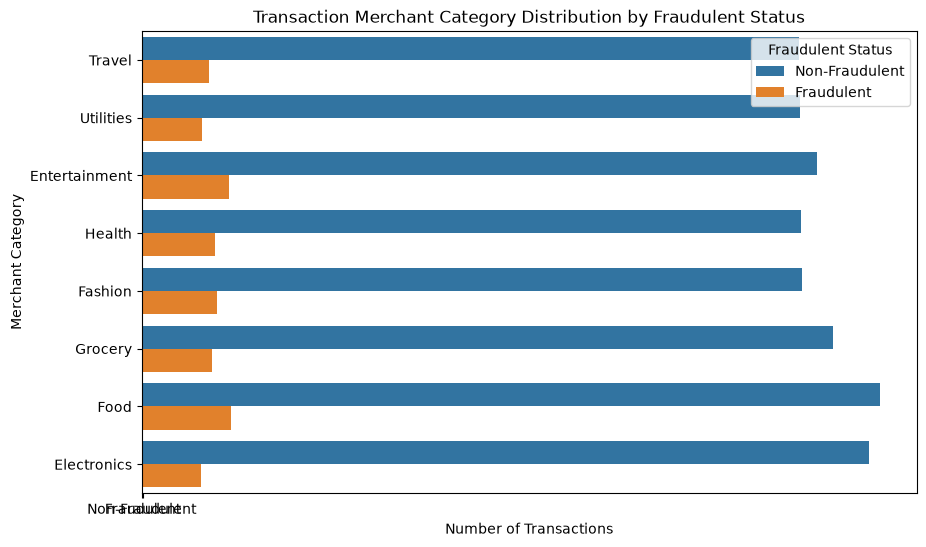

In [39]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='Merchant_Category', hue='Fraudulent')

plt.title('Transaction Merchant Category Distribution by Fraudulent Status')   
plt.xlabel('Number of Transactions')
plt.ylabel('Merchant Category')

plt.xticks(ticks=[0, 1], labels=['Non-Fraudulent', 'Fraudulent'])

plt.legend(title='Fraudulent Status', loc='upper right', labels=['Non-Fraudulent', 'Fraudulent'])

plt.show()


In [40]:
# Fraud rate by merchant category 
merchant_fraud_rate = df.groupby('Merchant_Category')['Fraudulent'].mean().sort_values(ascending=False)
merchant_fraud_rate


Merchant_Category
Entertainment    0.114286
Food             0.108187
Fashion          0.101974
Health           0.100660
Travel           0.093489
Grocery          0.092210
Utilities        0.084175
Electronics      0.075385
Name: Fraudulent, dtype: float64

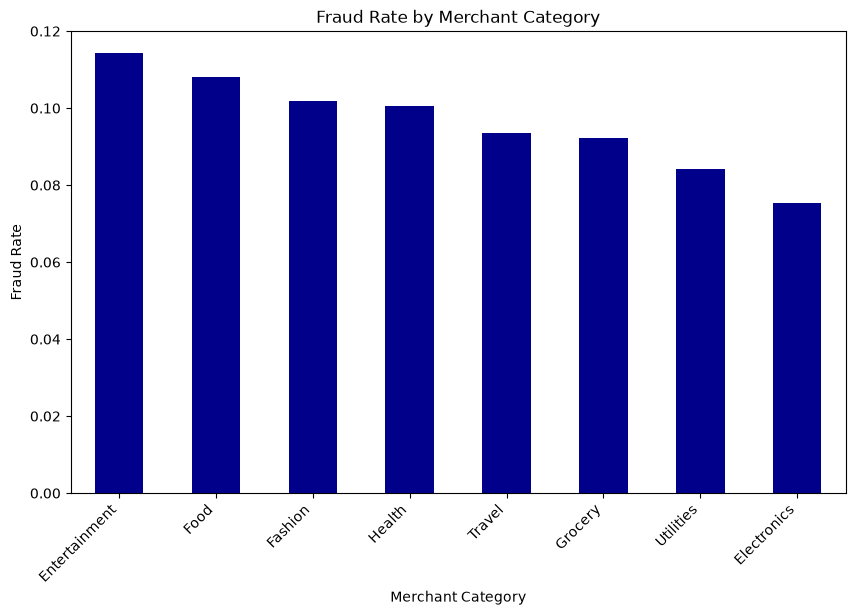

<Axes: xlabel='Fraudulent', ylabel='Transaction_Amount'>

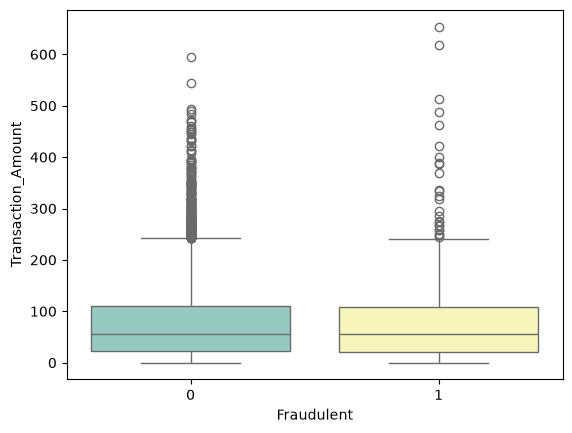

In [41]:
plt.figure(figsize=(10, 6))
merchant_fraud_rate.plot(kind='bar', color='darkblue')
plt.title('Fraud Rate by Merchant Category')
plt.xlabel('Merchant Category')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45, ha='right')
plt.show()

sns.boxplot(data=df, x='Fraudulent', y='Transaction_Amount', hue='Fraudulent', palette='Set3', legend=False)

In [42]:
# payment analysis

df["Payment_Method"].value_counts()

Payment_Method
NetBanking     1037
PayPal         1022
Debit Card     1008
Credit Card     972
UPI             961
Name: count, dtype: int64

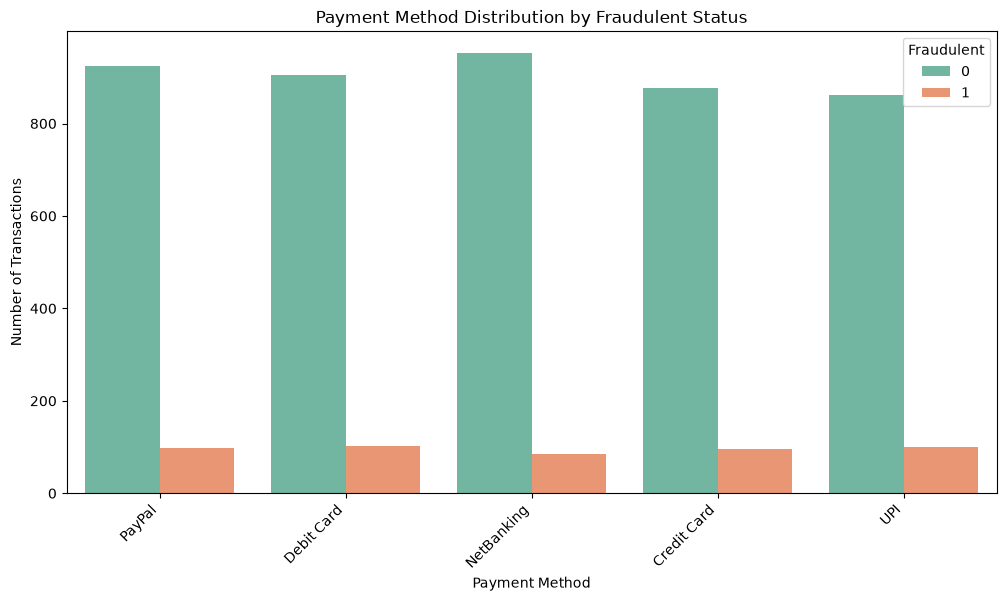

In [43]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Payment_Method', hue='Fraudulent', palette='Set2')    

plt.title('Payment Method Distribution by Fraudulent Status')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')
plt.show()  

In [44]:
# payment method by fraudrate

payment_fraud_rate = df.groupby('Payment_Method')['Fraudulent'].mean().sort_values(ascending=False)*100
payment_fraud_rate


Payment_Method
UPI            10.405827
Debit Card     10.218254
Credit Card     9.876543
PayPal          9.589041
NetBanking      8.196721
Name: Fraudulent, dtype: float64

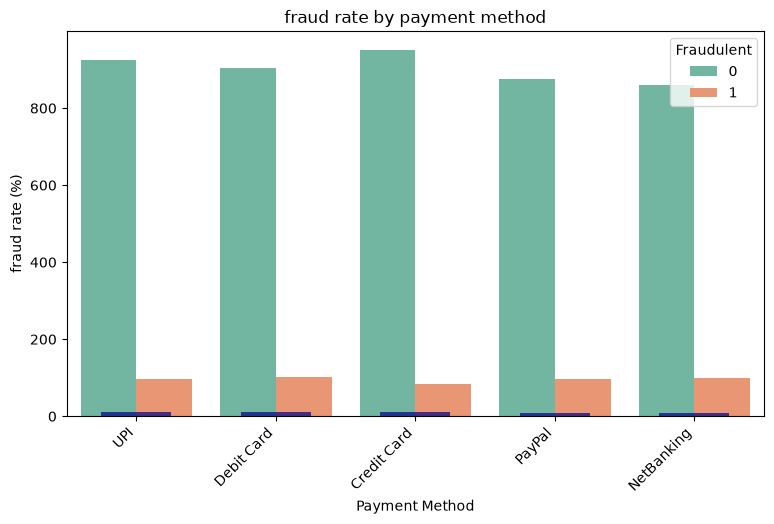

In [45]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x='Payment_Method', hue='Fraudulent', palette='Set2')

payment_fraud_rate.plot(kind='bar' , color='darkblue', alpha=0.7)

plt.title('fraud rate by payment method')
plt.xlabel('Payment Method')
plt.ylabel('fraud rate (%)')

plt.xticks(rotation=45, ha='right')
plt.show()

In [46]:
# device analysis

df["Device_Type"].value_counts()

Device_Type
Desktop    1679
POS        1673
Mobile     1648
Name: count, dtype: int64

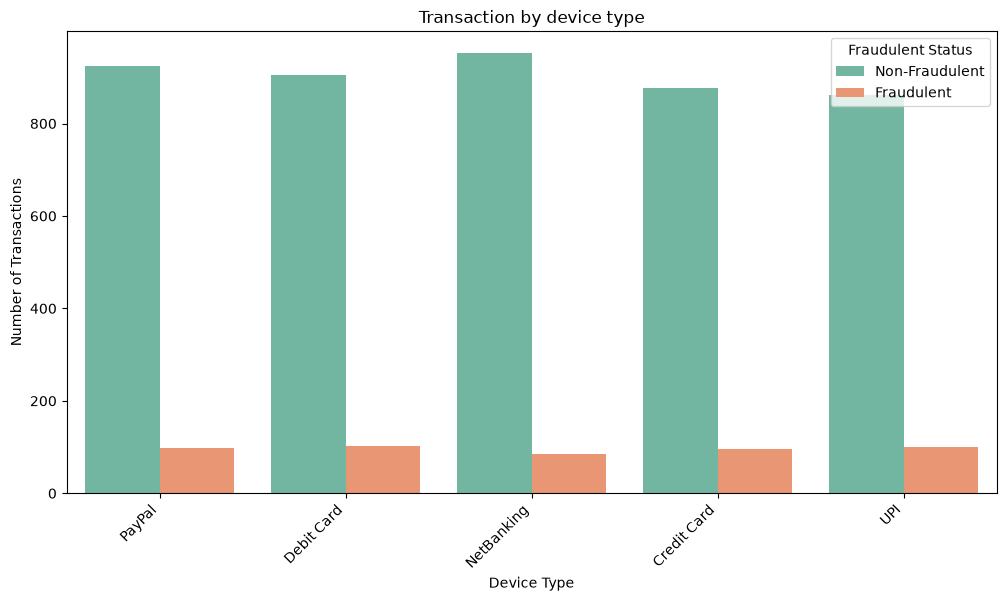

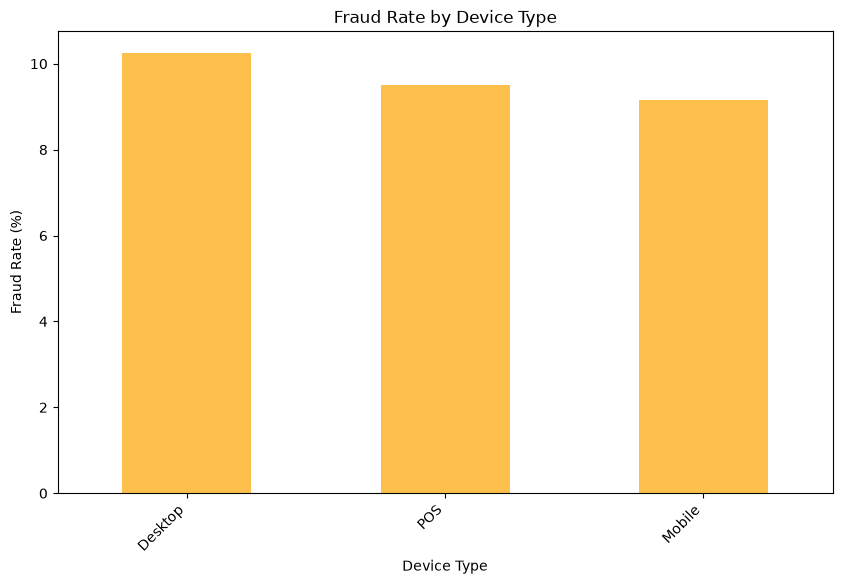

In [47]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Payment_Method', hue='Fraudulent', palette='Set2') 

plt.title('Transaction by device type')
plt.xlabel('Device Type')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Fraudulent Status', loc='upper right', labels=['Non-Fraudulent', 'Fraudulent'])

plt.show()


# analyzing device fraud-rate

device_fraud_rate = (
    df.groupby("Device_Type")["Fraudulent"]
    .mean()
    .sort_values(ascending=False)
    * 100
)

device_fraud_rate

plt.figure(figsize=(10, 6))
device_fraud_rate.plot(kind="bar", color="orange", alpha=0.7)

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=45, ha="right")
plt.show()

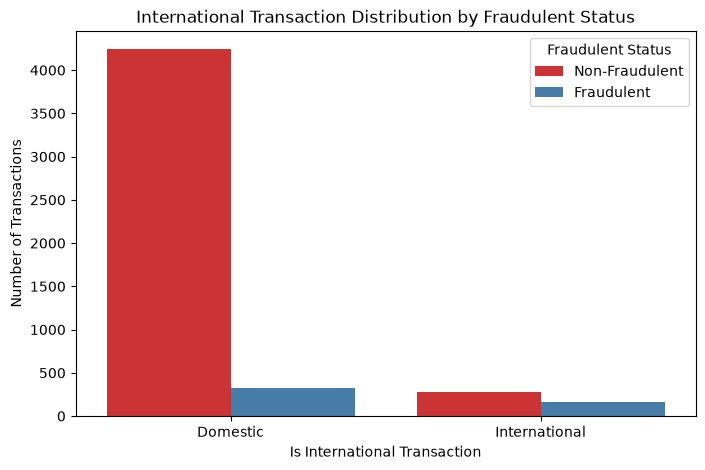

Is_International
1    36.961451
0     6.997148
Name: Fraudulent, dtype: float64

In [48]:
# internationa transaction analysis

df["Is_International"].value_counts()

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Is_International', hue='Fraudulent', palette='Set1')


plt.title('International Transaction Distribution by Fraudulent Status')
plt.xlabel('Is International Transaction')
plt.ylabel('Number of Transactions')

plt.xticks(ticks=[0, 1], labels=['Domestic', 'International'])
plt.legend(title='Fraudulent Status', loc='upper right', labels=['Non-Fraudulent', 'Fraudulent'])
plt.show()

international_fraud_rate = (
    df.groupby("Is_International")["Fraudulent"].mean().sort_values(ascending=False)* 100)
international_fraud_rate

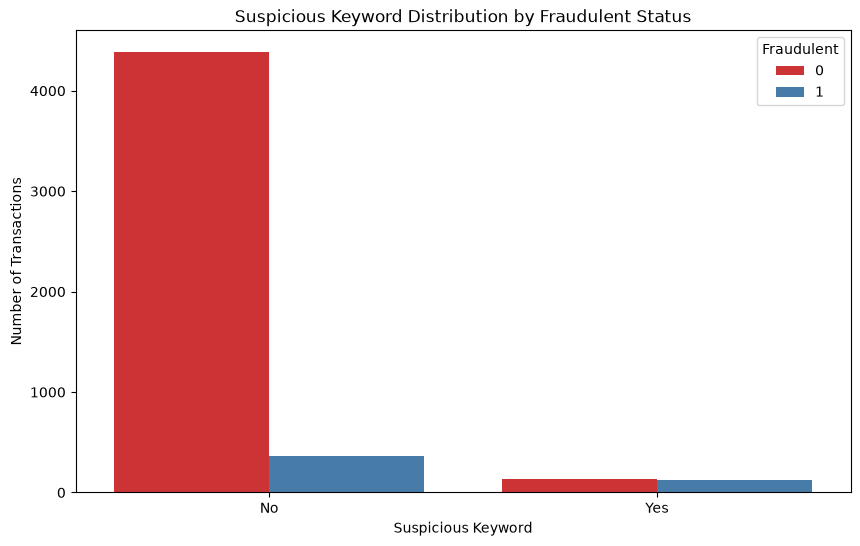

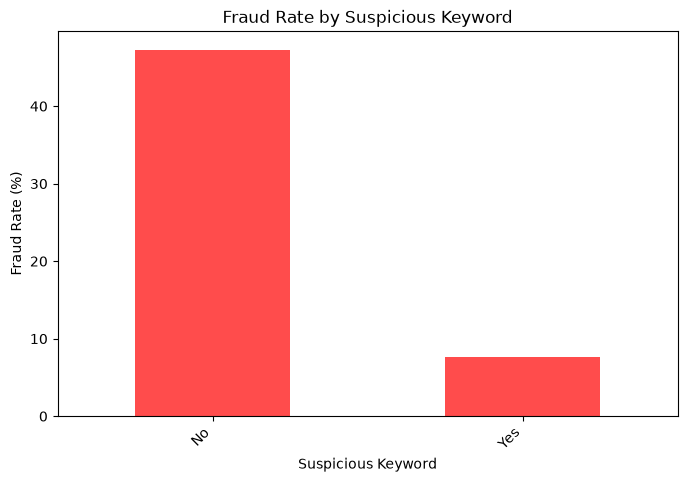

In [49]:
# suspicious analysis

df["Suspicious_Keyword"].value_counts()

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Suspicious_Keyword', hue='Fraudulent', palette='Set1')

plt.title('Suspicious Keyword Distribution by Fraudulent Status')
plt.xlabel('Suspicious Keyword')    
plt.ylabel('Number of Transactions')
plt.legend(title='Fraudulent')

plt.xticks(ticks=[0, 1], labels=['No', 'Yes'])
plt.show()


# fraud rate by suspicious keyword

suspicious_fraud_rate = (
    df.groupby("Suspicious_Keyword")["Fraudulent"].mean().sort_values(ascending=False)* 100)
suspicious_fraud_rate

plt.figure(figsize=(8, 5))
suspicious_fraud_rate.plot(kind="bar", color="red", alpha=0.7)
plt.title('Fraud Rate by Suspicious Keyword')
plt.xlabel('Suspicious Keyword')
plt.ylabel('Fraud Rate (%)')
plt.xticks(rotation = 45, ha='right', ticks=[0, 1], labels=['No', 'Yes']) 
plt.show()

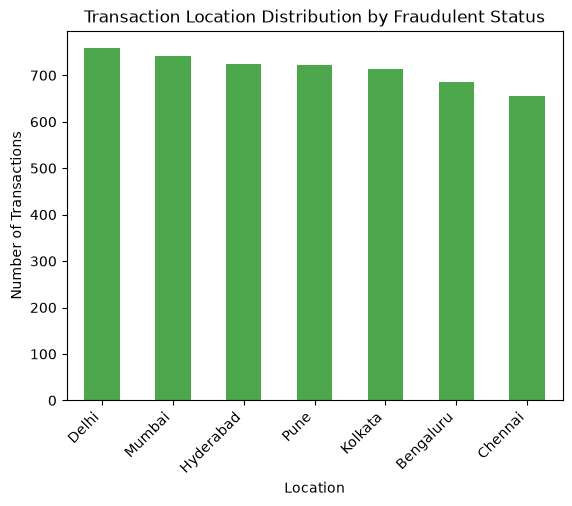

In [50]:
# Analyzing the location datsets
df["Location"].nunique()

df["Location"].value_counts()

top_locations = df["Location"].value_counts().head(10)

# sns.countplot(data=df, x='Location', hue='Fraudulent', palette='Set3')

top_locations.plot(kind='bar', color='green', alpha=0.7)

plt.title('Transaction Location Distribution by Fraudulent Status')
plt.xlabel('Location')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.show()


In [51]:
# fraud rate by location
location_summary = (
    df.groupby("Location")
    .agg(
        Total_Transactions=("Fraudulent", "count"),
        Fraudulent_Transactions=("Fraudulent", "sum"),
        Fraud_Rate=("Fraudulent", "mean")
    )
)

location_summary["Fraud_Rate"] = location_summary["Fraud_Rate"] * 100

location_summary.sort_values(
    "Fraud_Rate",
    ascending=False
).head(15)

,Total_Transactions,Fraudulent_Transactions,Fraud_Rate
Location,,,
Chennai,655,69,10.534351
Mumbai,741,78,10.526316
Bengaluru,686,71,10.349854
Kolkata,713,73,10.238429
Hyderabad,725,64,8.827586
Pune,722,62,8.587258
Delhi,758,65,8.575198


In [52]:
location_summary.columns

Index(['Total_Transactions', 'Fraudulent_Transactions', 'Fraud_Rate'], dtype='str')

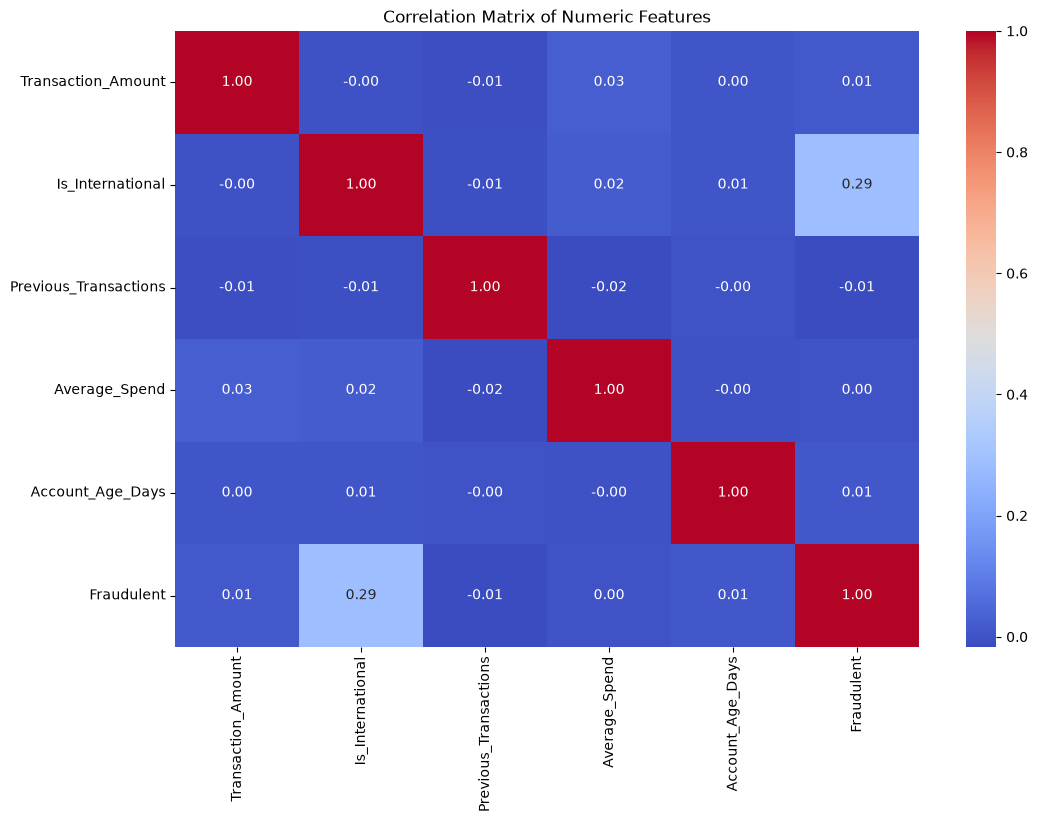

In [53]:
# corelation analysis for dataset

numeric_df = df.select_dtypes(include=["int64", "float64"])
correlation_matrix = numeric_df.corr()
correlation_matrix

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [70]:
df["Transaction_Hour"] = df["Transaction_Date"].dt.hour
print(df["Transaction_Hour"].head(10))

0     7
1     8
2    15
3    17
4     0
5     3
6     8
7    13
8    20
9    12
Name: Transaction_Hour, dtype: int32


In [72]:
hour_fraud = (
    df.groupby("Transaction_Hour")["Fraudulent"]
    .mean()
    .sort_index()
    * 100
)

print(hour_fraud)

Transaction_Hour
0     30.319149
1     23.529412
2     20.370370
3     27.000000
4     25.842697
5     27.118644
6      7.555556
7      3.365385
8      4.784689
9      5.000000
10     2.970297
11     4.878049
12     5.213270
13     5.579399
14     3.398058
15     4.081633
16     5.025126
17     2.283105
18     3.773585
19     5.050505
20     3.260870
21     5.188679
22     4.109589
23     4.545455
Name: Fraudulent, dtype: float64


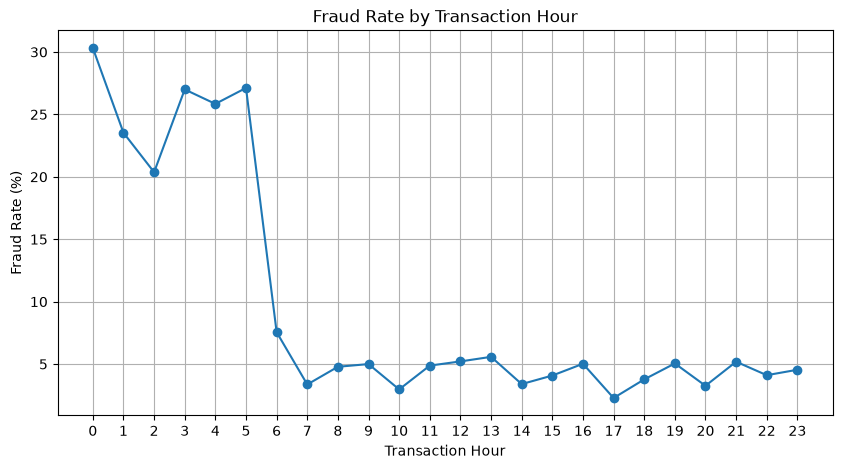

In [73]:
plt.figure(figsize=(10, 5))

plt.plot(hour_fraud.index, hour_fraud.values, marker="o")

plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

In [74]:
df["Day_of_Week"] = df["Transaction_Date"].dt.day_name()
print(df["Day_of_Week"].head(10))

0    Wednesday
1      Tuesday
2      Tuesday
3       Monday
4     Saturday
5       Sunday
6     Thursday
7       Sunday
8       Monday
9      Tuesday
Name: Day_of_Week, dtype: str


In [75]:
day_fraud = (
    df.groupby("Day_of_Week")["Fraudulent"]
    .mean()
    * 100
)

print(day_fraud)

Day_of_Week
Friday        7.782673
Monday       11.383285
Saturday      8.092486
Sunday       10.460251
Thursday      9.759358
Tuesday       9.861111
Wednesday    10.026738
Name: Fraudulent, dtype: float64


In [76]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_fraud = day_fraud.reindex(day_order)

print(day_fraud)

Day_of_Week
Monday       11.383285
Tuesday       9.861111
Wednesday    10.026738
Thursday      9.759358
Friday        7.782673
Saturday      8.092486
Sunday       10.460251
Name: Fraudulent, dtype: float64


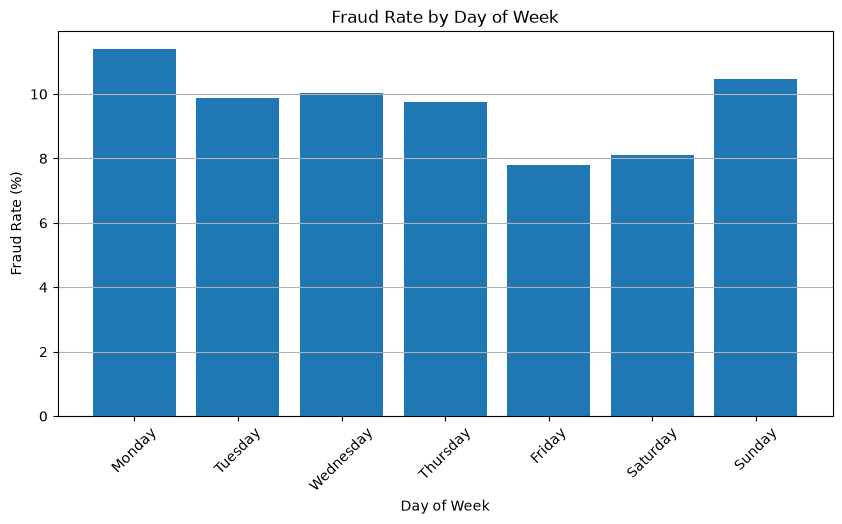

In [77]:
# visualizing fraud rate day to day
plt.figure(figsize=(10, 5))

plt.bar(day_fraud.index, day_fraud.values)

plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Day of Week")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [82]:
df["Transaction_Month"] = df["Transaction_Date"].dt.month
print(df["Transaction_Month"].head(10))

0    10
1     9
2     7
3    10
4     9
5     1
6     2
7     3
8     3
9     6
Name: Transaction_Month, dtype: int32


In [ ]:
#  fraud rate by month
df["Month"] = df["Transaction_Date"].dt.month
month_fraud = (
    df.groupby("Month")["Fraudulent"]
    .mean()
    * 100
)
print(month_fraud)

Month
1      9.874826
2      8.760331
3     10.344828
4     10.975610
5      7.969152
6      8.620690
7     10.204082
8      8.743169
9     10.840108
10    12.718204
11     8.179420
12     8.707865
Name: Fraudulent, dtype: float64


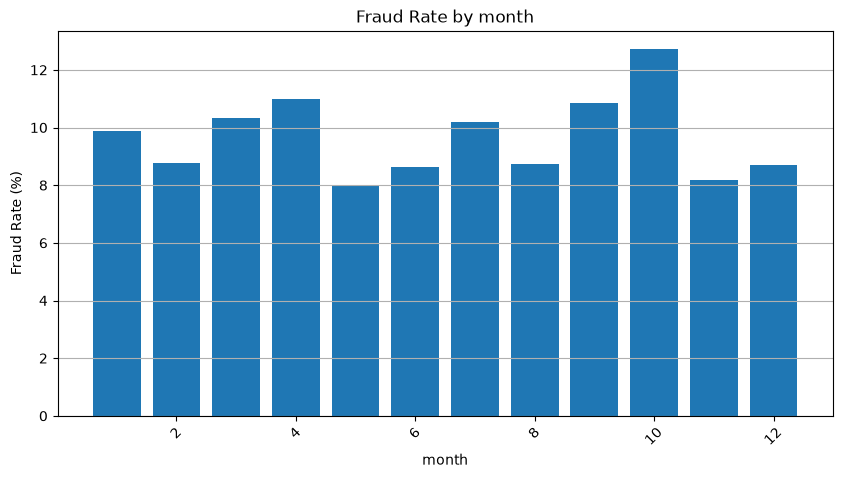

In [83]:
# visualizing fraud rate by month

plt.figure (figsize=(10, 5))

plt.bar(month_fraud.index, month_fraud.values)

plt.xlabel("month")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by month")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [54]:
# TIME Analysis

import pandas as pd

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

df["Hour"] = df["Transaction_Date"].dt.hour

fraud_by_hour =(

     df.groupby("Hour")["Fraudulent"]
     .mean()
     .sort_values(ascending=False)
)
print(fraud_by_hour)

Series([], Name: Fraudulent, dtype: float64)


In [71]:
print(df["Transaction_Date"].dtypes)
print(df["Transaction_Date"].head())
print("Missing dates:", df["Transaction_Date"].isnull().sum())

datetime64[us]
0   2023-10-04 07:45:00
1   2023-09-26 08:29:00
2   2023-07-18 15:54:00
3   2023-10-16 17:10:00
4   2023-09-09 00:46:00
Name: Transaction_Date, dtype: datetime64[us]
Missing dates: 0


In [56]:
# EDA summary

print("EDA completed successfully.")
print("Dataset shape:", df.shape)
print("Fraudulent transactions:", df["Fraudulent"].sum())
print("Non-fraudulent transactions:", (df["Fraudulent"] == 0).sum())

EDA completed successfully.
Dataset shape: (5000, 15)
Fraudulent transactions: 482
Non-fraudulent transactions: 4518
